# 🎬 Movie Genre Prediction
### TF-IDF + Logistic Regression / SVM / Naive Bayes
Dataset: IMDB Genre Classification (54,214 movies, 27 genres)

## Cell 1 — Imports & Configuration

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Paths ──────────────────────────────────────────────────────
TRAIN_PATH = r'C:\Users\vinnu\Downloads\Genre Classification Dataset\train_data.txt'
TEST_PATH  = r'C:\Users\vinnu\Downloads\Genre Classification Dataset\test_data.txt'
SOL_PATH   = r'C:\Users\vinnu\Downloads\Genre Classification Dataset\test_data_solution.txt'
OUTPUT_DIR = r'C:\Users\vinnu\Downloads\Genre Classification Dataset\outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Imports done')

✅ Imports done


## Cell 2 — Load Data

In [2]:
def load_train(path):
    records = []
    with open(path, encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) >= 4:
                records.append({'id': parts[0].strip(), 'title': parts[1].strip(),
                                 'genre': parts[2].strip(), 'description': parts[3].strip()})
    return pd.DataFrame(records)

def load_test(path):
    records = []
    with open(path, encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) >= 3:
                records.append({'id': parts[0].strip(), 'title': parts[1].strip(),
                                 'description': parts[2].strip()})
    return pd.DataFrame(records)

def load_solution(path):
    records = []
    with open(path, encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) >= 3:
                records.append({'id': parts[0].strip(), 'genre': parts[2].strip()})
    return pd.DataFrame(records)

print('📂 Loading data ...')
train_df = load_train(TRAIN_PATH)
test_df  = load_test(TEST_PATH)
sol_df   = load_solution(SOL_PATH)

print(f'   Train rows : {len(train_df):,}')
print(f'   Test  rows : {len(test_df):,}')
print(f'   Genres     : {train_df["genre"].nunique()}')
train_df.head(3)

📂 Loading data ...
   Train rows : 54,214
   Test  rows : 54,200
   Genres     : 27


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...


## Cell 3 — Text Preprocessing

In [3]:
STOP_WORDS_EXTRA = {
    'film','movie','one','two','story','life','man','woman',
    'time','day','year','new','made','make','also','get',
    'films','movies','show','tells','find','finds','found',
    'take','takes','taken','goes','come','comes','back',
    'around','another','s','t','re','ve','ll','d'
}

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in STOP_WORDS_EXTRA and len(w) > 2]
    return ' '.join(tokens)

print('🔧 Preprocessing text ...')
train_df['clean'] = (train_df['title'] + ' ' + train_df['description']).apply(preprocess)
test_df['clean']  = (test_df['title']  + ' ' + test_df['description']).apply(preprocess)

X_train = train_df['clean'].values
y_train = train_df['genre'].values
X_test  = test_df['clean'].values
y_test  = sol_df['genre'].values

print('✅ Preprocessing done')
print(f'   Sample: {X_train[0][:120]} ...')

🔧 Preprocessing text ...
✅ Preprocessing done
   Sample: oscar dame rose listening conversation between his doctor and parents old oscar learns what nobody has the courage tell  ...


## Cell 4 — Train All Models

In [4]:
tfidf_params = dict(max_features=100_000, ngram_range=(1,2), sublinear_tf=True,
                    min_df=2, max_df=0.95, stop_words='english')

models = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf',   LogisticRegression(max_iter=1000, C=5, solver='saga',
                                     multi_class='multinomial', n_jobs=-1))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf',   LinearSVC(max_iter=2000, C=1.0))
    ]),
    'Multinomial Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf',   MultinomialNB(alpha=0.1))
    ]),
}

results = {}
predictions = {}

for name, pipe in models.items():
    print(f'🚀 Training: {name} ...')
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    predictions[name] = preds
    acc    = accuracy_score(y_test, preds)
    f1_mac = f1_score(y_test, preds, average='macro',    zero_division=0)
    f1_wt  = f1_score(y_test, preds, average='weighted', zero_division=0)
    results[name] = {'Accuracy': acc, 'F1-Macro': f1_mac, 'F1-Weighted': f1_wt}
    print(f'   Accuracy: {acc:.4f}  |  F1-Macro: {f1_mac:.4f}  |  F1-Weighted: {f1_wt:.4f}')

best_name  = max(results, key=lambda k: results[k]['Accuracy'])
best_preds = predictions[best_name]
print(f'\n🏆 Best model: {best_name}')

🚀 Training: Logistic Regression ...
   Accuracy: 0.6055  |  F1-Macro: 0.3546  |  F1-Weighted: 0.5751
🚀 Training: Linear SVM ...
   Accuracy: 0.5972  |  F1-Macro: 0.3667  |  F1-Weighted: 0.5698
🚀 Training: Multinomial Naive Bayes ...
   Accuracy: 0.5511  |  F1-Macro: 0.2072  |  F1-Weighted: 0.4826

🏆 Best model: Logistic Regression


## Cell 5 — Classification Report

In [5]:
print(f'Classification Report — {best_name}\n')
print(classification_report(y_test, best_preds, zero_division=0))

Classification Report — Logistic Regression

              precision    recall  f1-score   support

      action       0.50      0.36      0.42      1314
       adult       0.70      0.37      0.48       590
   adventure       0.64      0.23      0.34       775
   animation       0.53      0.11      0.18       498
   biography       0.00      0.00      0.00       264
      comedy       0.56      0.61      0.59      7446
       crime       0.37      0.07      0.11       505
 documentary       0.70      0.85      0.77     13096
       drama       0.57      0.77      0.65     13612
      family       0.51      0.15      0.23       783
     fantasy       0.44      0.09      0.15       322
   game-show       0.89      0.58      0.70       193
     history       0.25      0.00      0.01       243
      horror       0.68      0.63      0.65      2204
       music       0.67      0.53      0.59       731
     musical       0.36      0.06      0.10       276
     mystery       0.30      0.03   

## 📊 Graph 1 — Genre Distribution in Training Data

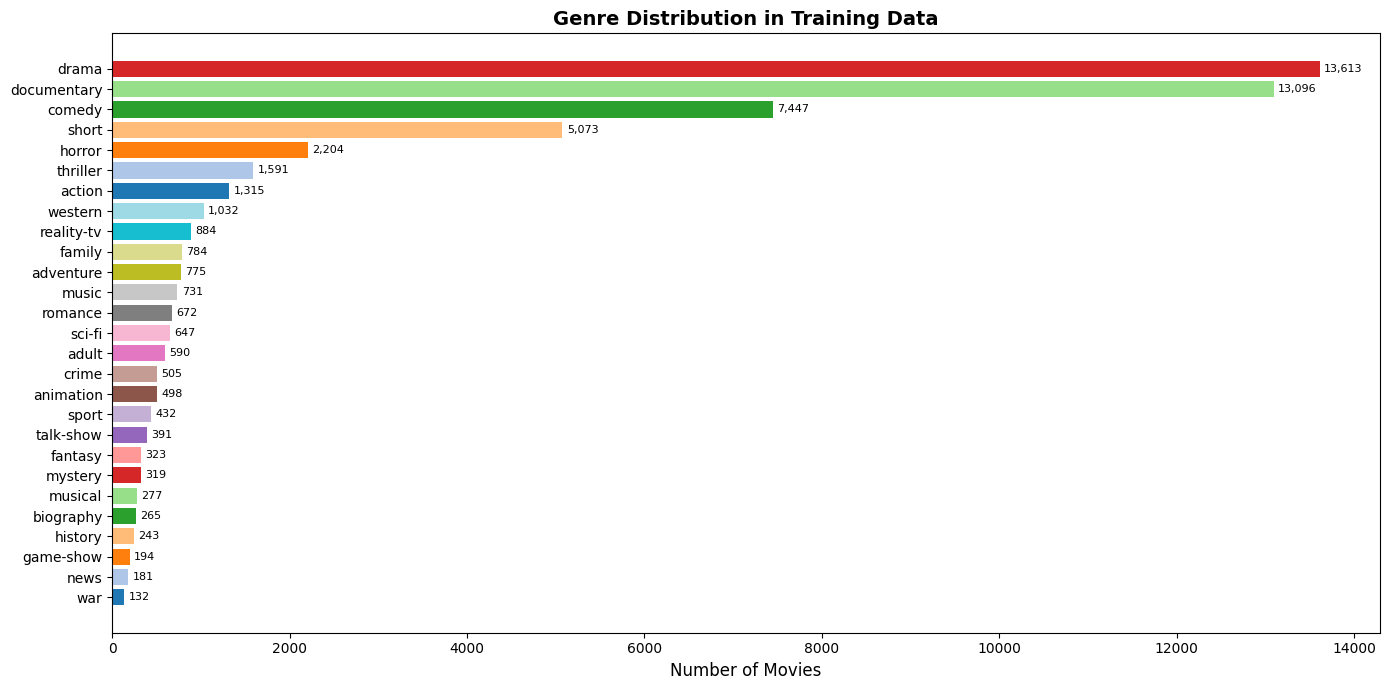

In [6]:
genre_counts  = Counter(y_train)
genres_sorted = sorted(genre_counts, key=genre_counts.get, reverse=True)
counts_sorted = [genre_counts[g] for g in genres_sorted]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(genres_sorted[::-1], counts_sorted[::-1], color=plt.cm.tab20.colors)
ax.set_xlabel('Number of Movies', fontsize=12)
ax.set_title('Genre Distribution in Training Data', fontsize=14, fontweight='bold')
for bar, cnt in zip(bars, counts_sorted[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 📊 Graph 2 — Model Performance Comparison

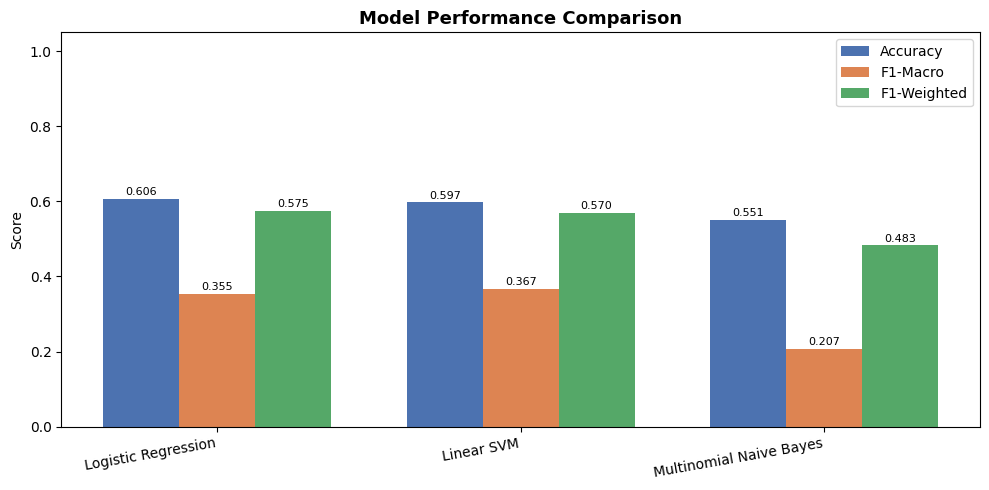

In [7]:
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_df))
width = 0.25
metric_list = ['Accuracy', 'F1-Macro', 'F1-Weighted']
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (metric, color) in enumerate(zip(metric_list, colors)):
    vals  = metrics_df[metric].values
    rects = ax.bar(x + i*width, vals, width, label=metric, color=color)
    for rect in rects:
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
                f'{rect.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_df['Model'], rotation=10, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 📊 Graph 3 — Confusion Matrix (Top 10 Genres)

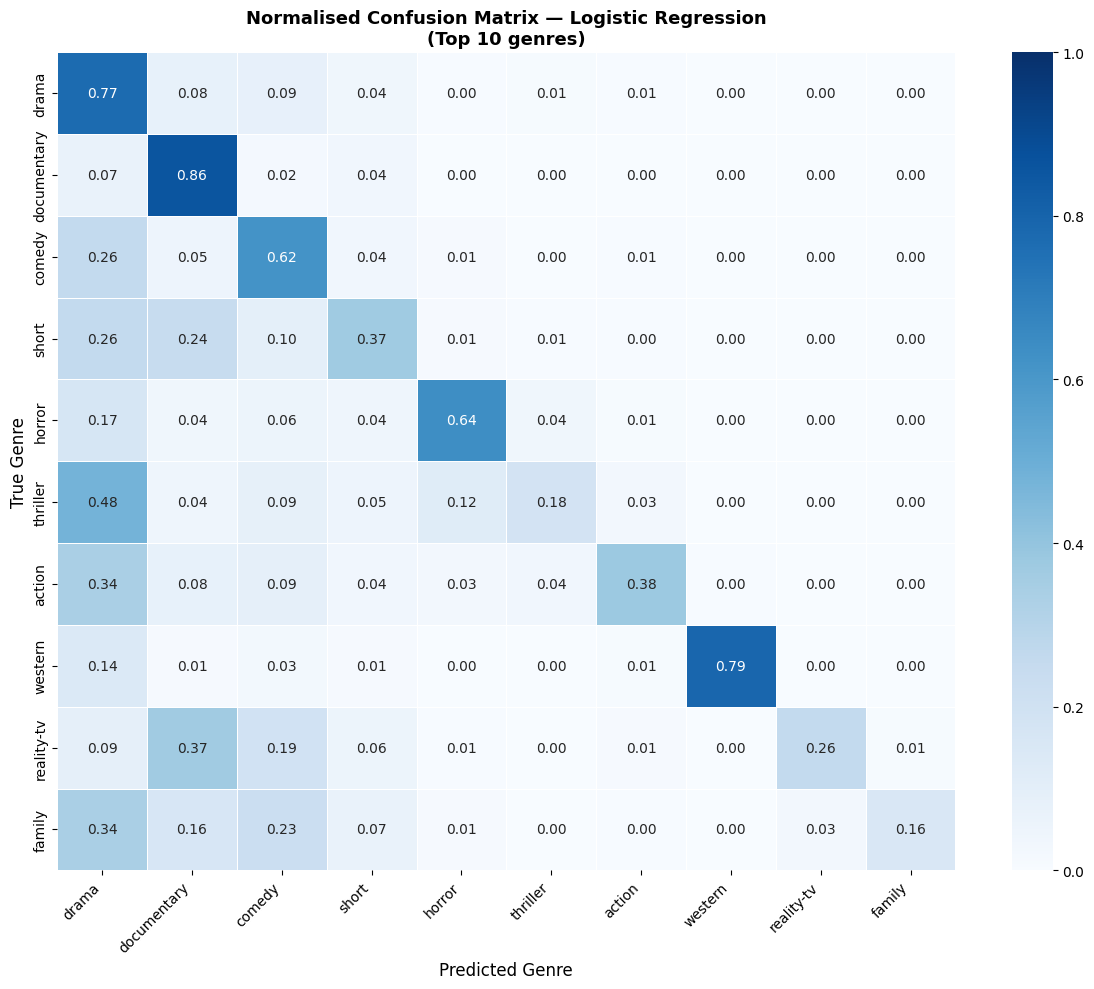

In [8]:
TOP_N      = 10
top_genres = [g for g, _ in Counter(y_test).most_common(TOP_N)]
mask       = np.isin(y_test, top_genres)
y_true_sub = y_test[mask]
y_pred_sub = best_preds[mask]
combined   = np.isin(y_pred_sub, top_genres)
y_true_sub = y_true_sub[combined]
y_pred_sub = y_pred_sub[combined]

cm      = confusion_matrix(y_true_sub, y_pred_sub, labels=top_genres)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top_genres, yticklabels=top_genres,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted Genre', fontsize=12)
ax.set_ylabel('True Genre', fontsize=12)
ax.set_title(f'Normalised Confusion Matrix — {best_name}\n(Top {TOP_N} genres)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 📊 Graph 4 — Per-Genre F1 Score

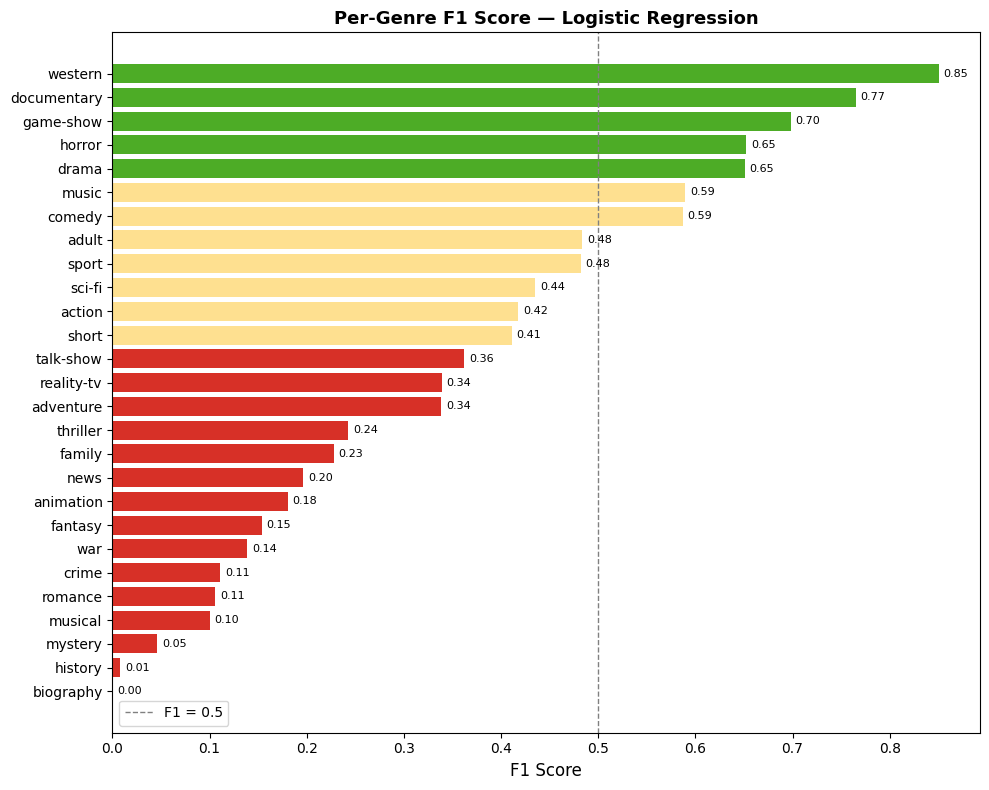

In [9]:
all_genres   = sorted(set(y_test))
f1_per_genre = f1_score(y_test, best_preds, labels=all_genres, average=None, zero_division=0)
f1_df        = pd.DataFrame({'Genre': all_genres, 'F1': f1_per_genre}).sort_values('F1')

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#d73027' if v < 0.4 else '#fee090' if v < 0.6 else '#4dac26'
              for v in f1_df['F1']]
ax.barh(f1_df['Genre'], f1_df['F1'], color=colors_bar)
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title(f'Per-Genre F1 Score — {best_name}', fontsize=13, fontweight='bold')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='F1 = 0.5')
ax.legend()
for i, (_, row) in enumerate(f1_df.iterrows()):
    ax.text(row['F1'] + 0.005, i, f"{row['F1']:.2f}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 📊 Graph 5 — Top Keywords per Genre

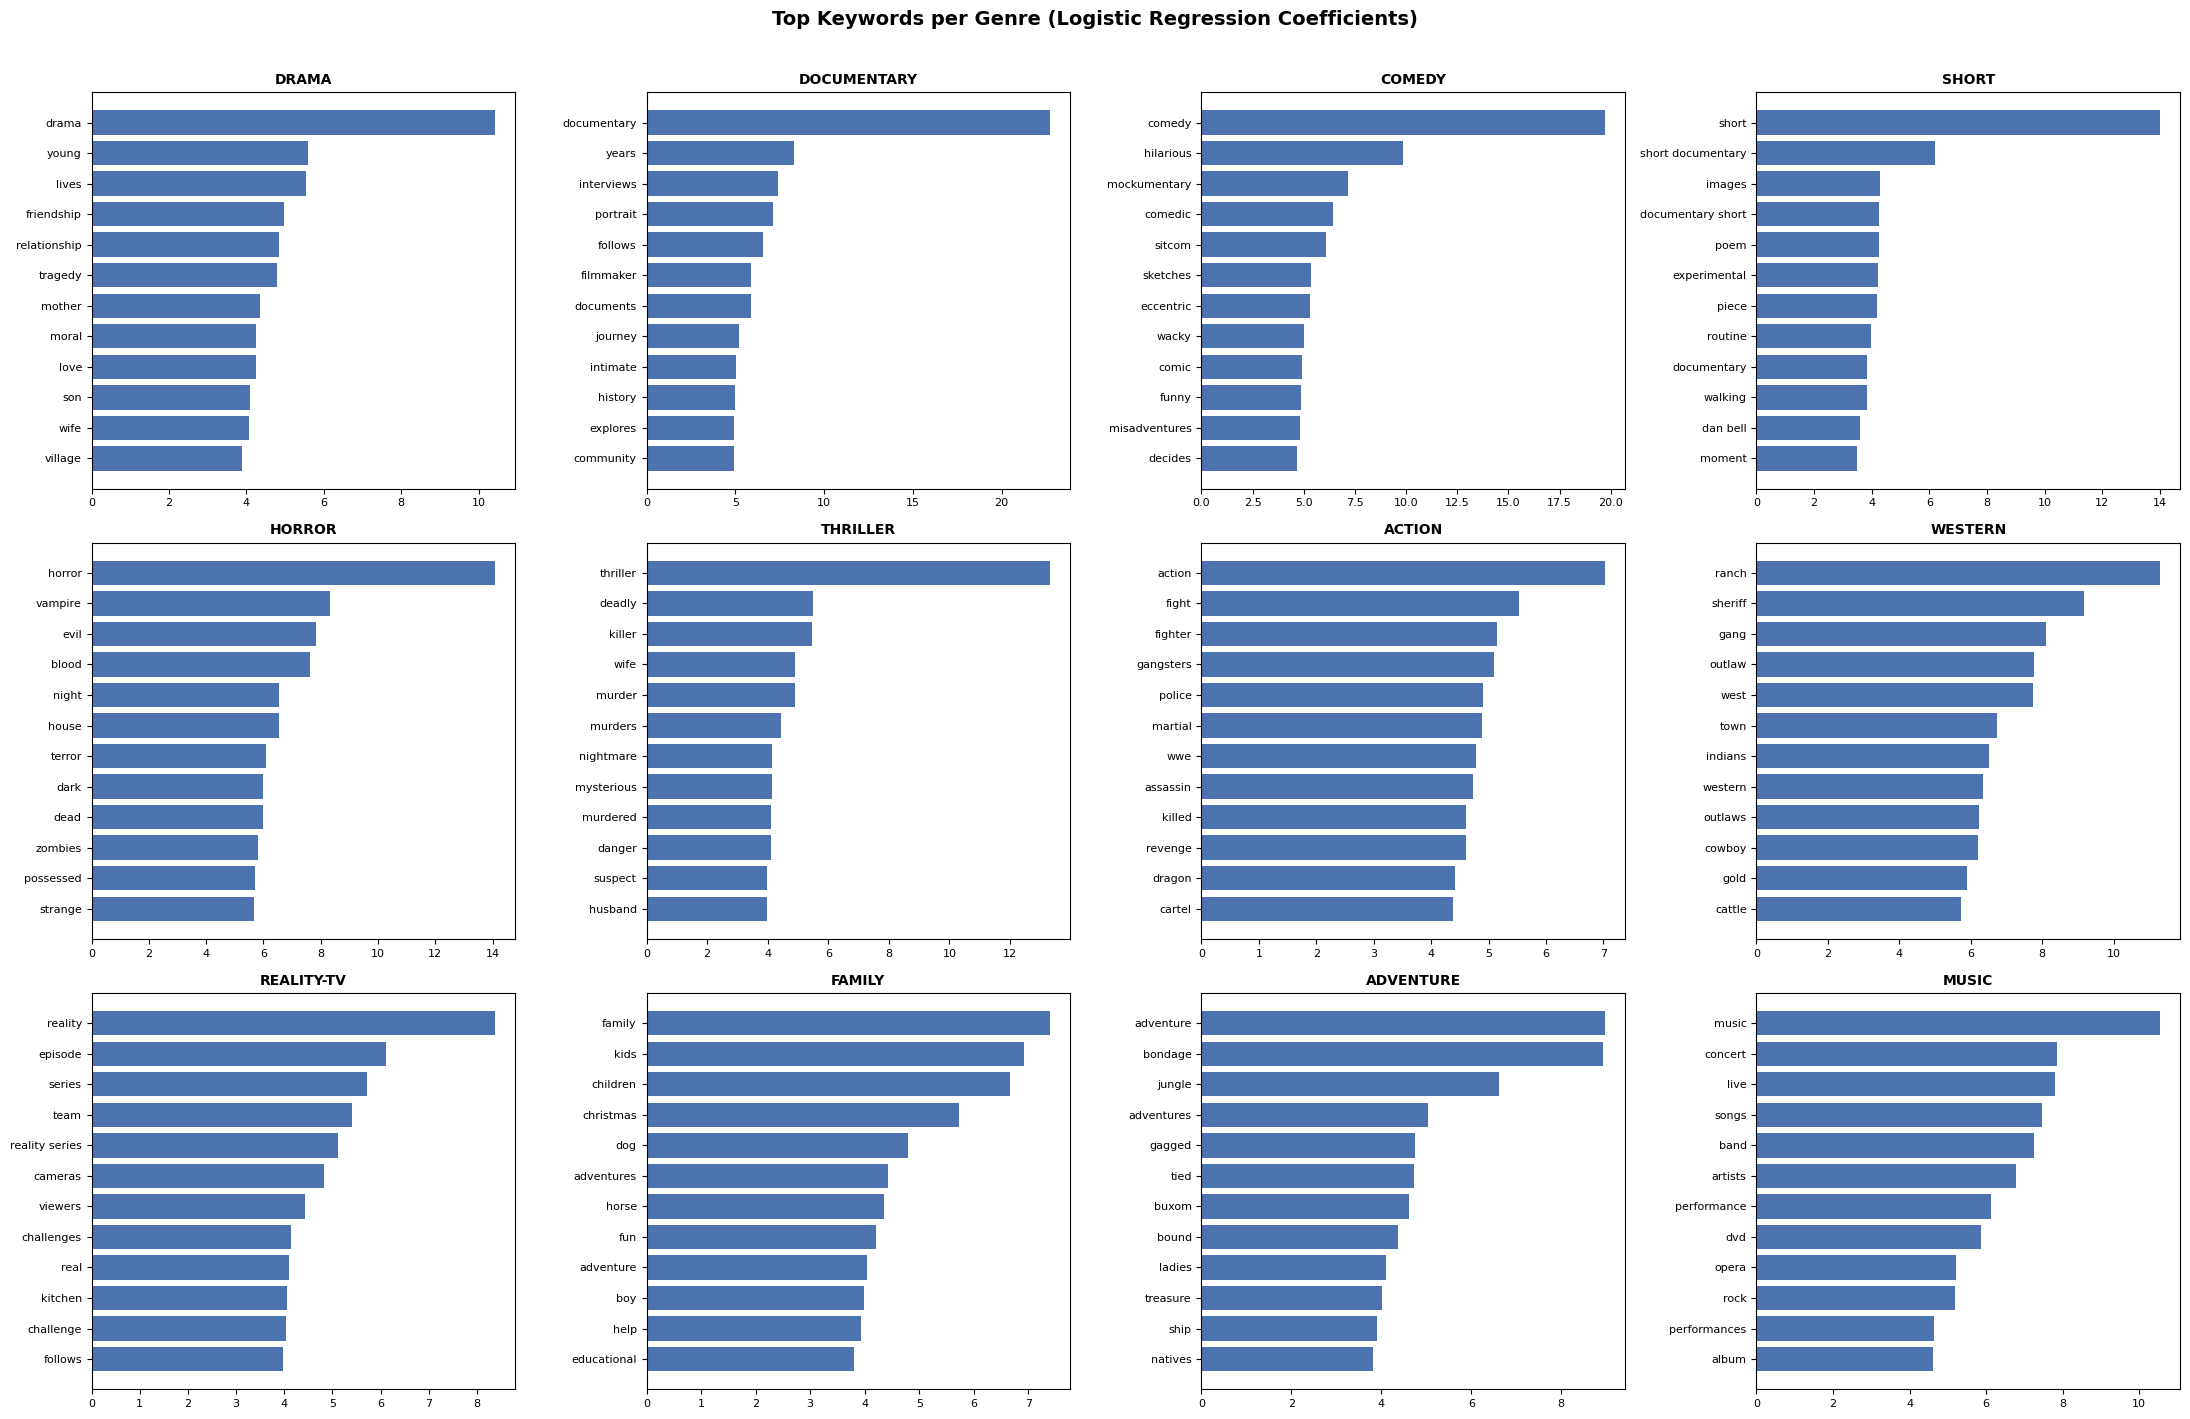

In [10]:
lr_pipe       = models['Logistic Regression']
vectorizer    = lr_pipe.named_steps['tfidf']
clf           = lr_pipe.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()
N_KEYWORDS    = 12
classes       = clf.classes_
show_genres   = [g for g, _ in Counter(y_train).most_common(12)]
class_indices = [list(classes).index(g) for g in show_genres if g in classes]

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()
for ax, class_idx in zip(axes, class_indices):
    genre    = classes[class_idx]
    top_idx  = np.argsort(clf.coef_[class_idx])[-N_KEYWORDS:]
    top_feats = feature_names[top_idx]
    top_coefs = clf.coef_[class_idx][top_idx]
    ax.barh(top_feats, top_coefs, color='#4C72B0')
    ax.set_title(genre.upper(), fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)
plt.suptitle('Top Keywords per Genre (Logistic Regression Coefficients)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Cell 11 — Save Predictions & Final Summary

In [11]:
pred_df = test_df[['id', 'title']].copy()
for name, preds in predictions.items():
    pred_df[name.lower().replace(' ', '_')] = preds
pred_df['best_prediction'] = predictions[best_name]
pred_df.to_csv(os.path.join(OUTPUT_DIR, 'predictions.csv'), index=False)
print(f'✅ Predictions saved to outputs/predictions.csv')

print('\n' + '='*55)
print('  FINAL RESULTS SUMMARY')
print('='*55)
for name, scores in results.items():
    marker = ' 🏆' if name == best_name else ''
    print(f'\n{name}{marker}')
    for metric, val in scores.items():
        print(f'   {metric:<15}: {val:.4f}')
print('='*55)

✅ Predictions saved to outputs/predictions.csv

  FINAL RESULTS SUMMARY

Logistic Regression 🏆
   Accuracy       : 0.6055
   F1-Macro       : 0.3546
   F1-Weighted    : 0.5751

Linear SVM
   Accuracy       : 0.5972
   F1-Macro       : 0.3667
   F1-Weighted    : 0.5698

Multinomial Naive Bayes
   Accuracy       : 0.5511
   F1-Macro       : 0.2072
   F1-Weighted    : 0.4826
